# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# При необходимости добавляйте новые ячейки для кода или текста

In [3]:
!pip install sqlalchemy 
!pip install phik

In [4]:
import pandas as pd
from sqlalchemy import create_engine
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)
engine = create_engine(connection_string)

In [5]:

import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [6]:
query = '''
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)
SELECT 
  p.user_id,
  p.device_type_canonical,
  p.order_id,
  p.created_dt_msk AS order_dt,
  p.created_ts_msk AS order_ts,
  p.currency_code,
  p.revenue,
  p.tickets_count,
  EXTRACT(DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)))::INTEGER AS days_since_prev,
  p.event_id,
  e.event_name_code AS event_name,
  e.event_type_main,
  p.service_name,
  r.region_name,
  c.city_name
FROM afisha.purchases p
JOIN afisha.events e ON p.event_id = e.event_id
JOIN afisha.city c ON e.city_id = c.city_id
JOIN afisha.regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id
'''
df = pd.read_sql_query(query, con=engine)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Выгружено 290 611 заказов за 2024 год

Данные содержат 15 столбцов с информацией о пользователях, заказах, мероприятиях

Пропуски только в days_since_prev (21 933) — это корректно для первых заказов пользователей

Типы данных: даты преобразованы в datetime, числовые данные в int64/float64

Объём данных достаточен для репрезентативного анализа

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [7]:
val =pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')
print(val)
val['data'] = pd.to_datetime(val['data']).dt.date
val['c']=val['curs']/100
cdic = dict(zip(val['data'],val['c']))
print(val)

           data  nominal     curs  cdx
0    2024-01-10      100  19.9391  kzt
1    2024-01-11      100  19.7255  kzt
2    2024-01-12      100  19.5839  kzt
3    2024-01-13      100  19.4501  kzt
4    2024-01-14      100  19.4501  kzt
..          ...      ...      ...  ...
352  2024-12-27      100  19.2705  kzt
353  2024-12-28      100  19.5105  kzt
354  2024-12-29      100  19.4860  kzt
355  2024-12-30      100  19.4860  kzt
356  2024-12-31      100  19.4860  kzt

[357 rows x 4 columns]
           data  nominal     curs  cdx         c
0    2024-01-10      100  19.9391  kzt  0.199391
1    2024-01-11      100  19.7255  kzt  0.197255
2    2024-01-12      100  19.5839  kzt  0.195839
3    2024-01-13      100  19.4501  kzt  0.194501
4    2024-01-14      100  19.4501  kzt  0.194501
..          ...      ...      ...  ...       ...
352  2024-12-27      100  19.2705  kzt  0.192705
353  2024-12-28      100  19.5105  kzt  0.195105
354  2024-12-29      100  19.4860  kzt  0.194860
355  2024-12-30   

In [8]:
df['order_data'] = pd.to_datetime(df['order_dt']).dt.date

In [9]:
df['revenue_rub']=df['revenue']
df.loc[df['currency_code']=='kzt','revenue_rub'] = df.loc[df['currency_code']=='kzt','revenue']*df.loc[df['currency_code']=='kzt','order_data'].map(cdic)
df.drop('order_data',axis =1,inplace = True)

In [10]:
df['revenue_rub']=round(df['revenue_rub'],2)
print(df)

                user_id device_type_canonical  order_id   order_dt  \
0       0002849b70a3ce2                mobile   4359165 2024-08-20   
1       0005ca5e93f2cf4                mobile   7965605 2024-07-23   
2       0005ca5e93f2cf4                mobile   7292370 2024-10-06   
3       000898990054619                mobile   1139875 2024-07-13   
4       000898990054619                mobile    972400 2024-10-04   
...                 ...                   ...       ...        ...   
290606  fffcd3dde79eb2c                mobile    368591 2024-10-27   
290607  fffcd3dde79eb2c                mobile    368562 2024-10-27   
290608  fffcd3dde79eb2c               desktop   8473772 2024-10-30   
290609  fffeeb3c120cf0b               desktop   5526067 2024-09-24   
290610  ffff00725179321                mobile    813654 2024-09-25   

                  order_ts currency_code  revenue  tickets_count  \
0      2024-08-20 16:08:03           rub  1521.94              4   
1      2024-07-23 18:36

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [11]:
print(df.info())
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [12]:
df['currency_code'].unique()
df['event_type_main'].unique()
df['service_name'].unique()
df['region_name'].unique()
df['city_name'].unique()
df['device_type_canonical'].unique()

array(['mobile', 'desktop'], dtype=object)

In [13]:
df['revenue_rub'].describe(percentiles=[0.01, 0.5, 0.75, 0.99])

count    290611.000000
mean        555.571989
std         875.498170
min         -90.760000
1%            0.000000
50%         351.140000
75%         802.050000
99%        2628.420000
max       81174.540000
Name: revenue_rub, dtype: float64

In [14]:
df['tickets_count'].describe(percentiles=[0.01, 0.5, 0.75, 0.99])

count    290611.000000
mean          2.754311
std           1.170620
min           1.000000
1%            1.000000
50%           3.000000
75%           4.000000
99%           6.000000
max          57.000000
Name: tickets_count, dtype: float64

<AxesSubplot:ylabel='Frequency'>

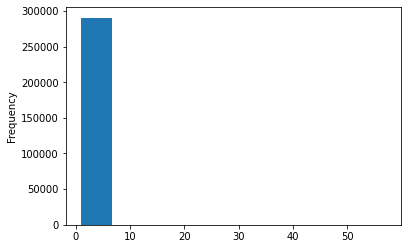

In [15]:
df['tickets_count'].plot(kind ='hist')


<AxesSubplot:ylabel='Frequency'>

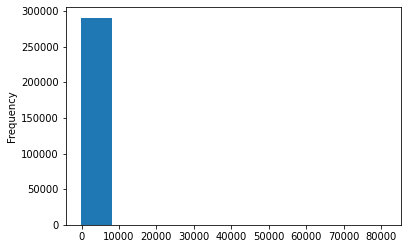

In [16]:
df['revenue_rub'].plot(kind ='hist')

<AxesSubplot:>

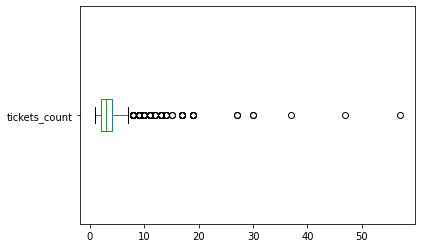

In [17]:
df['tickets_count'].plot(kind='box', vert=False)

<AxesSubplot:>

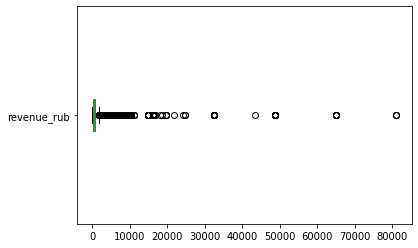

In [18]:
df['revenue_rub'].plot(kind='box', vert=False)

In [19]:
initial_count = len(df)
df = df[df['revenue_rub'] >= 0]
revenue_99 = df['revenue_rub'].quantile(0.99)
df = df[df['revenue_rub'] <= revenue_99]
print(f"Удалено записей: {initial_count - len(df)}")

Удалено записей: 3206


Пропуски только в days_since_prev (7.5% от всех записей) — это пользователи с единственным заказом

В revenue_rub обнаружены отрицательные значения (мин -90.76 руб.) — удалены

В revenue_rub обнаружены выбросы до 81 174 руб. — отфильтрованы по 99 перцентилю (2 628 руб.)

В tickets_count максимум 57 билетов (99% = 6) — оставлено без фильтрации

Всего удалено 3 206 записей (1.1% от исходных данных)

Добавлен новый столбец revenue_rub — выручка в рублях (тенге сконвертированы по курсу)



---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [20]:
df = df.sort_values(['user_id', 'order_dt'])
user_profile = df.groupby('user_id').agg(
    first_order=('order_dt', 'first'),
    last_order=('order_dt', 'last'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_genre=('event_type_main', 'first'),
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean'),
    avg_days_between=('days_since_prev', 'mean')
).reset_index()
print(user_profile)
user_profile['is_two'] = (user_profile['total_orders'] >= 2)
user_profile['is_five'] = (user_profile['total_orders'] >= 5)

               user_id first_order last_order first_device  \
0      0002849b70a3ce2  2024-08-20 2024-08-20       mobile   
1      0005ca5e93f2cf4  2024-07-23 2024-10-06       mobile   
2      000898990054619  2024-07-13 2024-10-23       mobile   
3      00096d1f542ab2b  2024-08-15 2024-08-15      desktop   
4      000a55a418c128c  2024-09-29 2024-10-15       mobile   
...                ...         ...        ...          ...   
21833  fff13b79bd47d7c  2024-07-16 2024-10-31       mobile   
21834  fff32fc9ad0f9f6  2024-08-15 2024-10-28      desktop   
21835  fffcd3dde79eb2c  2024-06-20 2024-10-30      desktop   
21836  fffeeb3c120cf0b  2024-09-24 2024-09-24      desktop   
21837  ffff00725179321  2024-09-25 2024-09-25       mobile   

               first_region       first_service first_genre  total_orders  \
0        Каменевский регион        Край билетов       театр             1   
1        Каменевский регион           Мой билет    выставки             2   
2      Североярская обла

In [21]:
print(user_profile)

               user_id first_order last_order first_device  \
0      0002849b70a3ce2  2024-08-20 2024-08-20       mobile   
1      0005ca5e93f2cf4  2024-07-23 2024-10-06       mobile   
2      000898990054619  2024-07-13 2024-10-23       mobile   
3      00096d1f542ab2b  2024-08-15 2024-08-15      desktop   
4      000a55a418c128c  2024-09-29 2024-10-15       mobile   
...                ...         ...        ...          ...   
21833  fff13b79bd47d7c  2024-07-16 2024-10-31       mobile   
21834  fff32fc9ad0f9f6  2024-08-15 2024-10-28      desktop   
21835  fffcd3dde79eb2c  2024-06-20 2024-10-30      desktop   
21836  fffeeb3c120cf0b  2024-09-24 2024-09-24      desktop   
21837  ffff00725179321  2024-09-25 2024-09-25       mobile   

               first_region       first_service first_genre  total_orders  \
0        Каменевский регион        Край билетов       театр             1   
1        Каменевский регион           Мой билет    выставки             2   
2      Североярская обла

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [22]:
print(len(user_profile))
print(round(user_profile['avg_revenue_rub'].mean(),2))
print(round((user_profile['is_two'].sum())/(len(user_profile)),2))
print(round((user_profile['is_five'].sum())/(len(user_profile)),2))

21838
545.03
0.62
0.29


In [23]:
print(user_profile['total_orders'].describe(percentiles=[0.5, 0.75,0.95, 0.99]))
print(user_profile['avg_tickets'].describe(percentiles=[0.5, 0.75, 0.95, 0.99]))
print(user_profile['avg_days_between'].describe(percentiles=[0.5, 0.75,0.95, 0.99]))

count    21838.000000
mean        13.160775
std        121.577370
min          1.000000
50%          2.000000
75%          5.000000
95%         31.000000
99%        152.000000
max      10168.000000
Name: total_orders, dtype: float64
count    21838.000000
mean         2.744062
std          0.913083
min          1.000000
50%          2.750000
75%          3.080000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets, dtype: float64
count    13511.000000
mean        15.847068
std         22.304516
min          0.000000
50%          8.000000
75%         20.414286
95%         61.500000
99%        112.000000
max        148.000000
Name: avg_days_between, dtype: float64


In [24]:
orders_99 = user_profile['total_orders'].quantile(0.99)
user_profile = user_profile[user_profile['total_orders'] <= orders_99].copy()
print(user_profile['total_orders'].describe(percentiles=[0.5, 0.75,0.95, 0.99]))

count    21622.000000
mean         6.496624
std         14.310784
min          1.000000
50%          2.000000
75%          5.000000
95%         26.000000
99%         79.790000
max        152.000000
Name: total_orders, dtype: float64


Всего пользователей: 21 838

Средняя выручка на заказ: 545.03 руб.

Доля пользователей с 2+ заказами: 62%

Доля пользователей с 5+ заказами: 29%

Выявлены аномалии в total_orders: максимум 10 168 заказов (один пользователь). Отфильтровано по 99 перцентилю (152 заказа)

После фильтрации среднее число заказов снизилось с 13.16 до 6.5

Данные репрезентативны, аномалии обработаны

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [25]:
seg1 = user_profile.groupby('first_genre').agg(users=('user_id', 'count'))
seg1['per']=round(seg1['users']/len(user_profile),2)
print(seg1)

             users   per
first_genre             
выставки       415  0.02
другое        5407  0.25
концерты      9565  0.44
спорт          799  0.04
стендап       1111  0.05
театр         4230  0.20
ёлки            95  0.00


In [26]:
seg2 = user_profile.groupby('first_device').agg(users=('user_id', 'count'))
seg2['per']=round(seg2['users']/len(user_profile),2)
print(seg2)

              users   per
first_device             
desktop        3739  0.17
mobile        17883  0.83


In [27]:
seg3 = user_profile.groupby('first_region').agg(users=('user_id', 'count'))
seg3['per']=round(seg3['users']/len(user_profile),2)
seg3=seg3.sort_values('users',ascending = False)
print(seg3.head(10))

                      users   per
first_region                     
Каменевский регион     7089  0.33
Североярская область   3766  0.17
Широковская область    1221  0.06
Озернинский край        677  0.03
Малиновоярский округ    527  0.02
Шанырский регион        500  0.02
Травяная область        487  0.02
Светополянский округ    456  0.02
Речиновская область     438  0.02
Яблоневская область     411  0.02


In [28]:
seg4 = user_profile.groupby('first_service').agg(users=('user_id', 'count'))
seg4['per']=round(seg4['users']/len(user_profile),2)
print(seg4)

                        users   per
first_service                      
Crazy ticket!              48  0.00
Show_ticket               159  0.01
Билет по телефону           6  0.00
Билеты без проблем       5153  0.24
Билеты в руки            2562  0.12
Быстробилет               161  0.01
Быстрый кассир             62  0.00
Весь в билетах           1279  0.06
Восьмёрка                  85  0.00
Вперёд!                     7  0.00
Выступления.ру             97  0.00
Городской дом культуры    217  0.01
Дом культуры              356  0.02
За билетом!               206  0.01
Зе Бест!                    1  0.00
КарандашРУ                 15  0.00
Кино билет                  9  0.00
Край билетов              454  0.02
Лимоны                      2  0.00
Лови билет!              2808  0.13
Лучшие билеты            1189  0.05
Мир касс                  207  0.01
Мой билет                2974  0.14
Облачко                  2179  0.10
Прачечная                 581  0.03
Радио ticket               3

По жанру первого мероприятия: концерты составляют 44% пользователей, другое — 25%, театр — 20%

По типу устройства: мобильные устройства доминируют с долей 83%, десктоп — 17%

По регионам: Каменевский регион концентрирует 33% пользователей, топ-3 региона дают 56% всех пользователей

По билетным операторам: «Билеты без проблем» занимает 24%, «Мой билет» — 14%, «Лови билет!» — 13%

Вывод: распределение пользователей неравномерно, есть выраженные «точки входа» — мобильные устройства, концерты, Каменевский регио

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


             users  users_two  share_two
first_genre                             
концерты      9565       5913       0.62
другое        5407       3223       0.60
театр         4230       2678       0.63
стендап       1111        677       0.61
спорт          799        448       0.56
выставки       415        267       0.64
ёлки            95         53       0.56


<AxesSubplot:xlabel='first_genre'>

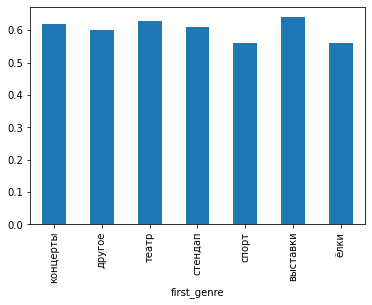

In [29]:
seg1 = user_profile.groupby('first_genre').agg(
    users=('user_id', 'count'),
    users_two=('is_two', 'sum')
)
seg1['share_two'] = round(seg1['users_two'] / seg1['users'] , 2)
seg1=seg1.sort_values('users',ascending = False)
print(seg1)
seg1['share_two'].plot(kind ='bar')

              users  users_two  share_two
first_device                             
mobile        17883      10864       0.61
desktop        3739       2395       0.64


<AxesSubplot:xlabel='first_device'>

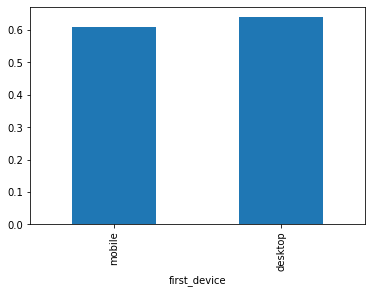

In [30]:
seg2 = user_profile.groupby('first_device').agg(
    users=('user_id', 'count'),
    users_two=('is_two', 'sum')
)
seg2['share_two'] = round(seg2['users_two'] / seg2['users'] , 2)
seg2=seg2.sort_values('users',ascending = False)
print(seg2)
seg2['share_two'].plot(kind ='bar')

                      users  users_two  share_two
first_region                                     
Каменевский регион     7089       4424       0.62
Североярская область   3766       2403       0.64
Широковская область    1221        786       0.64
Озернинский край        677        375       0.55
Малиновоярский округ    527        295       0.56
Шанырский регион        500        336       0.67
Травяная область        487        299       0.61
Светополянский округ    456        299       0.66
Речиновская область     438        277       0.63
Яблоневская область     411        244       0.59


<AxesSubplot:xlabel='first_region'>

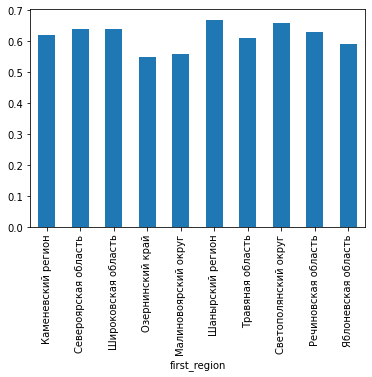

In [31]:
seg3 = user_profile.groupby('first_region').agg(
    users=('user_id', 'count'),
    users_two=('is_two', 'sum')
)
seg3['share_two'] = round(seg3['users_two'] / seg3['users'] , 2)
seg3=seg3.sort_values('users',ascending = False)
print(seg3.head(10))
seg3['share_two'].head(10).plot(kind ='bar')

                        users  users_two  share_two
first_service                                      
Билеты без проблем       5153       3103       0.60
Мой билет                2974       1812       0.61
Лови билет!              2808       1710       0.61
Билеты в руки            2562       1610       0.63
Облачко                  2179       1335       0.61
Весь в билетах           1279        802       0.63
Лучшие билеты            1189        732       0.62
Прачечная                 581        363       0.62
Край билетов              454        296       0.65
Дом культуры              356        230       0.65
Яблоко                    317        169       0.53
Тебе билет!               309        187       0.61
Городской дом культуры    217        128       0.59
Мир касс                  207        132       0.64
За билетом!               206        123       0.60
Быстробилет               161         95       0.59
Show_ticket               159        104       0.65
Выступления.

<AxesSubplot:xlabel='first_service'>

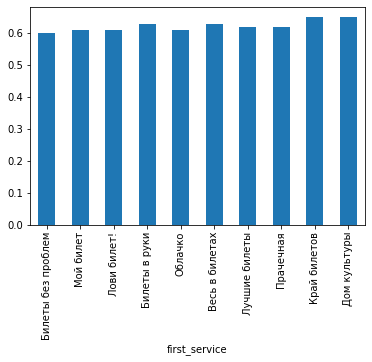

In [32]:
seg4 = user_profile.groupby('first_service').agg(
    users=('user_id', 'count'),
    users_two=('is_two', 'sum')
)
seg4['share_two'] = round(seg4['users_two'] / seg4['users'] , 2)
seg4=seg4.sort_values('users',ascending = False)
print(seg4)
seg4['share_two'].head(10).plot(kind ='bar')

По жанрам: самая высокая доля возвратов у выставок (64%), театра (63%) и концертов (62%)

По устройствам: десктоп-пользователи возвращаются чаще (64%) по сравнению с мобильными (61%)

По регионам (среди крупных): Североярская и Широковская области (64%), Каменевский регион (62%)

По операторам (среди крупных): «Край билетов» (65%), «Дом культуры» (65%), «Билеты в руки» (63%)

Успешные «точки входа» (выше среднего 62%): десктоп-пользователи, жанры «выставки» и «театр»

Сегменты с малым числом пользователей (Быстрый кассир, Реестр) показывают нестабильные доли, их интерпретация требует осторожности

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Гипотеза о том, что пользователи, начавшие со спорта, возвращаются чаще, чем начавшие с концертов, не подтвердилась. Напротив, спорт показывает более низкий возврат (56%) по сравнению с концертами (62%). Гипотеза о том, что в более активных регионах выше доля повторных заказов, подтвердилась: в топ-5 регионах возврат составляет 62-64%, тогда как в менее активных регионах — 55-59%.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


Text(0, 0.5, 'Плотность распределения')

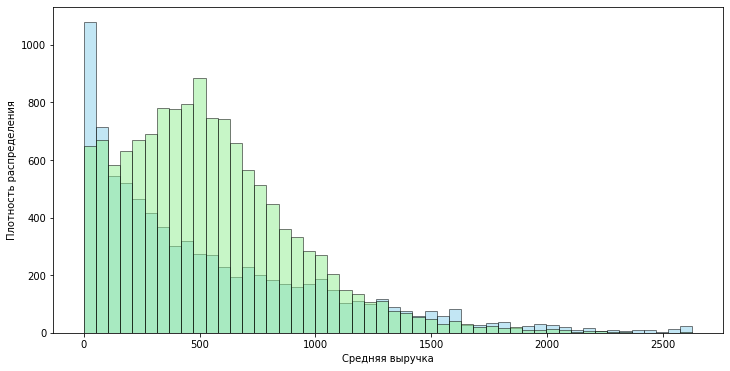

In [33]:
seg421=user_profile[user_profile['total_orders']==1]
seg431=user_profile[user_profile['total_orders']>=2]
plt.figure(figsize=(12, 6))

seg421['avg_revenue_rub'].plot(kind='hist', bins=50, alpha=0.5, color='skyblue', 
                               edgecolor='black')

seg431['avg_revenue_rub'].plot(kind='hist', bins=50, alpha=0.5, color='lightgreen', 
                               edgecolor='black')

plt.xlabel('Средняя выручка')
plt.ylabel('Плотность распределения')

In [34]:
print(seg421['avg_revenue_rub'].describe())
print(seg431['avg_revenue_rub'].describe())

count    8363.000000
mean      545.774760
std       519.402522
min         0.000000
25%       133.055000
50%       378.870000
75%       830.975000
max      2628.420000
Name: avg_revenue_rub, dtype: float64
count    13259.000000
mean       545.070666
std        369.285424
min          0.000000
25%        271.682500
50%        496.543333
75%        745.630577
max       2628.420000
Name: avg_revenue_rub, dtype: float64


Пользователи с 1 заказом концентрируются в диапазоне от 133 до 831 рубля. Пользователи с 2+ заказами концентрируются в диапазоне от 272 до 746 рублей.Да, различия есть. У вернувшихся пользователей медианная выручка выше (497 руб. против 379 руб.), а разброс значений уже (474 руб. против 698 руб.). Пользователи с 2+ заказами тратят больше и ведут себя более однородно, в то время как пользователи с одним заказом чаще совершают как очень маленькие, так и очень крупные покупки. Таким образом, более высокая и стабильная выручка связана с повторными заказами.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


Text(0, 0.5, 'Плотность распределения')

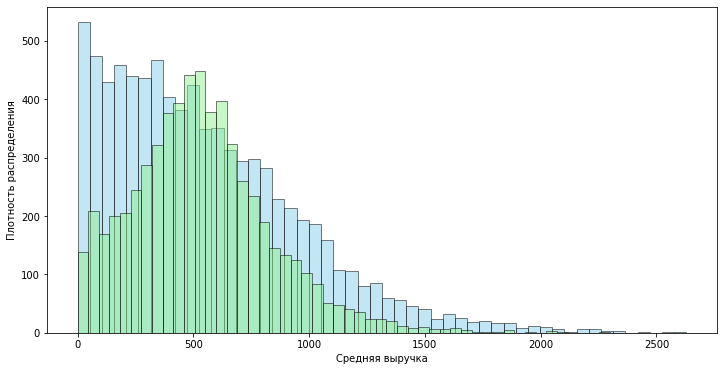

In [35]:
seg42 = user_profile[(user_profile['total_orders']>=2)&(user_profile['total_orders']<=5)]
seg43=user_profile[user_profile['total_orders']>=5]
plt.figure(figsize=(12, 6))

seg42['avg_revenue_rub'].plot(kind='hist', bins=50, alpha=0.5, color='skyblue', 
                               edgecolor='black')

seg43['avg_revenue_rub'].plot(kind='hist', bins=50, alpha=0.5, color='lightgreen', 
                               edgecolor='black')

plt.xlabel('Средняя выручка')
plt.ylabel('Плотность распределения')

In [36]:
print(seg42['avg_revenue_rub'].describe())
print(seg43['avg_revenue_rub'].describe())

count    8112.000000
mean      551.460113
std       412.153543
min         0.000000
25%       224.850000
50%       476.302500
75%       795.706875
max      2628.420000
Name: avg_revenue_rub, dtype: float64
count    6116.000000
mean      536.605246
std       298.957801
min         0.000000
25%       331.692137
50%       513.309000
75%       700.967911
max      2299.867500
Name: avg_revenue_rub, dtype: float64


Да, различия есть. Пользователи с 5+ заказами имеют более высокую медианную выручку (513 руб. против 476 руб.) и более узкий диапазон концентрации (332-701 руб. против 225-796 руб.). Это означает, что пользователи с большим количеством заказов тратят больше и ведут себя более стабильно. Пользователи с 2-5 заказами показывают больший разброс и склонность к более низким тратам. Таким образом, чем больше заказов совершает пользователь, тем выше его средняя выручка и стабильнее поведение.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [37]:
print(user_profile['avg_tickets'].describe(percentiles=[0.5, 0.75, 0.9, 0.99]))
plt.figure(figsize=(12, 6))
def ticket_segment(avg_tickets):
    if avg_tickets < 2:
        return '1-2 билета'
    elif avg_tickets < 3:
        return '2-3 билета'
    elif avg_tickets < 5:
        return '3-5 билетов'
    else:
        return '5+ билетов'

user_profile['ticket_segment'] = user_profile['avg_tickets'].apply(ticket_segment)
segt = user_profile.groupby('ticket_segment').agg(users=('user_id', 'count'),users_two=('is_two', 'sum'))
segt['ratio'] =round(segt['users_two']/segt['users'],2)
print(segt)

count    21622.000000
mean         2.744256
std          0.917491
min          1.000000
50%          2.750000
75%          3.100000
90%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets, dtype: float64
                users  users_two  ratio
ticket_segment                         
1-2 билета       2410       1235   0.51
2-3 билета       9487       6979   0.74
3-5 билетов      9064       4921   0.54
5+ билетов        661        124   0.19


<Figure size 864x432 with 0 Axes>

Распределение пользователей по среднему количеству билетов сконцентрировано в сегментах 2-3 билета (44%) и 3-5 билетов (42%). Самую высокую долю возвратов показывает сегмент 2-3 билета — 74%, тогда как сегмент 5+ билетов имеет аномально низкую долю возвратов всего 19%. Это говорит о том, что пользователи, покупающие много билетов за раз, реже возвращаются на платформу.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [38]:
user_profile['first_weekday'] = user_profile['first_order'].dt.weekday

In [39]:
segd = user_profile.groupby('first_weekday').agg(users=('user_id', 'count'),users_two=('is_two', 'sum'))
segd['ratio'] =round(segd['users_two']/segd['users'],2)
print(segd)

               users  users_two  ratio
first_weekday                         
0               2918       1838   0.63
1               3175       1965   0.62
2               3061       1906   0.62
3               3112       1850   0.59
4               3256       1946   0.60
5               3323       2086   0.63
6               2777       1668   0.60


Text(0, 0.5, 'Количество пользователей / Доля повторных покупок')

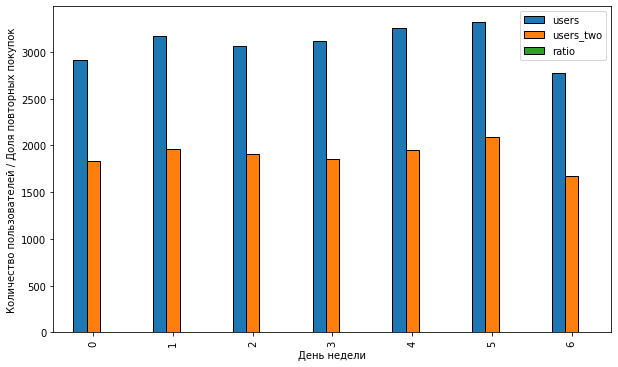

In [40]:
segd.plot(kind='bar', figsize=(10, 6), edgecolor='black')

plt.xlabel('День недели')
plt.ylabel('Количество пользователей / Доля повторных покупок')

День недели первой покупки практически не влияет на вероятность возврата клиента. Разница между лучшим днём (понедельник и суббота с 63%) и худшим (четверг с 59%) составляет всего 4%, что можно считать незначительным.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [41]:
group1 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
group2= user_profile[user_profile['total_orders'] >= 5]
print(round(group1['avg_days_between'].mean(),2))
print(round(group2['avg_days_between'].mean(),2))

21.33
9.91


Пользователи с 5 и более заказами возвращаются в среднем через 10 дней, тогда как пользователи с 2-4 заказами возвращаются через 21 день. Таким образом, чем короче интервал между заказами, тем больше заказов совершает пользователь, и скорость возврата является ключевым фактором удержания клиентов.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [42]:
print(user_profile.columns.tolist())

['user_id', 'first_order', 'last_order', 'first_device', 'first_region', 'first_service', 'first_genre', 'total_orders', 'avg_revenue_rub', 'avg_tickets', 'avg_days_between', 'is_two', 'is_five', 'ticket_segment', 'first_weekday']


In [43]:
cols_for_corr = ['total_orders', 'avg_revenue_rub', 'avg_tickets', 'avg_days_between', 'first_weekday']
correlation_matrix = user_profile[cols_for_corr].phik_matrix()
corr_with_rating = correlation_matrix[['total_orders']].sort_values(by='total_orders', ascending=False)
print(corr_with_rating)


interval columns not set, guessing: ['total_orders', 'avg_revenue_rub', 'avg_tickets', 'avg_days_between', 'first_weekday']
                  total_orders
total_orders          1.000000
avg_days_between      0.283370
avg_tickets           0.225326
avg_revenue_rub       0.219467
first_weekday         0.059635


In [44]:
user_profile['segment'] = '1 заказ'
user_profile.loc[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4), 'segment'] = '2-4 заказа'
user_profile.loc[user_profile['total_orders'] >= 5, 'segment'] = '5+ заказов'

interval columns not set, guessing: ['total_orders', 'avg_revenue_rub', 'avg_tickets', 'avg_days_between', 'first_weekday']
                  total_orders
total_orders          1.000000
avg_days_between      0.385079
avg_tickets           0.369235
avg_revenue_rub       0.108652
first_weekday         0.000000


<AxesSubplot:>

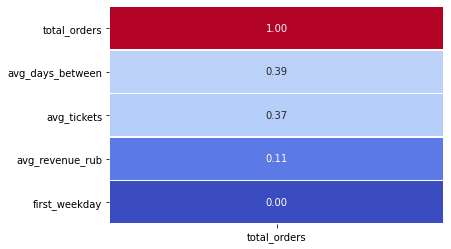

In [45]:
data2 = user_profile[user_profile['segment'] == '2-4 заказа'][cols_for_corr]
d1 = data2.phik_matrix()[['total_orders']].sort_values(by='total_orders', ascending=False)
print(d1)
sns.heatmap(d1,
            annot=True, 
            fmt='.2f',
            cmap='coolwarm', 
            linewidths=0.5,
            cbar=False
           )

interval columns not set, guessing: ['total_orders', 'avg_revenue_rub', 'avg_tickets', 'avg_days_between', 'first_weekday']
                  total_orders
total_orders          1.000000
avg_days_between      0.695582
avg_revenue_rub       0.238056
avg_tickets           0.162151
first_weekday         0.101997


<AxesSubplot:>

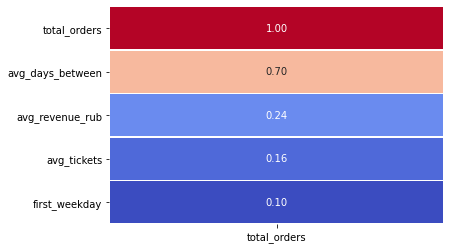

In [46]:
data3 = user_profile[user_profile['segment'] == '5+ заказов'][cols_for_corr]
d2 = data3.phik_matrix()[['total_orders']].sort_values(by='total_orders', ascending=False)
print(d2)
sns.heatmap(d2,
            annot=True, 
            fmt='.2f',
            cmap='coolwarm', 
            linewidths=0.5,
            cbar=False
           )

На всех пользователях сильнее всего с числом заказов коррелируют средний интервал между заказами (0.28), среднее количество билетов (0.23) и средняя выручка (0.22). День недели практически не коррелирует (0.06). В сегменте 5+ заказов корреляция с интервалом возрастает до 0.70, что делает интервал между заказами самым сильным предиктором общего числа заказов пользователя.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

Проанализировано 290 611 заказов от 21 838 пользователей за 2024 год. Данные очищены от выбросов, тенговые заказы сконвертированы в рубли. Ключевой фактор удержания — скорость возврата: пользователи с 5+ заказами возвращаются в 2 раза быстрее (10 дней против 21 дня). Десктоп-пользователи демонстрируют более высокую лояльность (64%) чем мобильные (61%). Спортивные мероприятия показывают более низкий возврат (56%) по сравнению с концертами (62%). Рекомендуется запустить программу стимулирования повторных покупок в первые 10 дней после заказа, усилить удержание спортивной аудитории, разработать специальные предложения для пользователей, покупающих 5+ билетов, сконцентрировать маркетинговые усилия на топ-3 регионах, а также обратить внимание на успешных операторов «Край билетов» и «Дом культуры», которые показывают лучшую лояльность (65%).

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**

https://github.com/aspergerchild/project_yandex